In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"bank-full.csv", sep=";")

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (45211, 17)

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [2]:
print(df["y"].value_counts())

print("\nTarget percentages:")
print(df["y"].value_counts(normalize=True) * 100)

y
no     39922
yes     5289
Name: count, dtype: int64

Target percentages:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [3]:
X = df.drop("y", axis=1)

print("Number of instances:", X.shape[0])
print("Number of features:", X.shape[1])

Number of instances: 45211
Number of features: 16


In [4]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print(df.describe(include="all").T)

Duplicate rows: 0
             count unique          top   freq         mean          std  \
age        45211.0    NaN          NaN    NaN     40.93621    10.618762   
job          45211     12  blue-collar   9732          NaN          NaN   
marital      45211      3      married  27214          NaN          NaN   
education    45211      4    secondary  23202          NaN          NaN   
default      45211      2           no  44396          NaN          NaN   
balance    45211.0    NaN          NaN    NaN  1362.272058  3044.765829   
housing      45211      2          yes  25130          NaN          NaN   
loan         45211      2           no  37967          NaN          NaN   
contact      45211      3     cellular  29285          NaN          NaN   
day        45211.0    NaN          NaN    NaN    15.806419     8.322476   
month        45211     12          may  13766          NaN          NaN   
duration   45211.0    NaN          NaN    NaN    258.16308   257.527812   
campaig

In [6]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("y", axis=1)
y = df["y"]

# Convert target to binary values
# no = 0, yes = 1
y = y.map({"no": 0, "yes": 1})

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (36168, 16)
Testing set shape: (9043, 16)

Training target distribution:
y
0    31937
1     4231
Name: count, dtype: int64

Testing target distribution:
y
0    7985
1    1058
Name: count, dtype: int64


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nNumber of categorical features:",
      len(categorical_features))

print("Number of numerical features:",
      len(numerical_features))

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Preprocessor created successfully.
X_train: (36168, 16)
X_test : (9043, 16)
y_train: (36168,)
y_test : (9043,)

Number of categorical features: 9
Number of numerical features: 7


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Define the six models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="linear",
        probability=False,
        random_state=42
    )
}

# Create pipelines
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

print("All 6 model pipelines created successfully.")

for name in pipelines:
    print("-", name)

All 6 model pipelines created successfully.
- Logistic Regression
- Decision Tree
- KNN
- Naive Bayes
- Random Forest
- SVM


In [9]:
trained_models = {}

for name, pipeline in pipelines.items():

    print(f"Training {name}...")

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

print("\nAll models trained successfully!")

Training Logistic Regression...
Logistic Regression trained successfully.
Training Decision Tree...
Decision Tree trained successfully.
Training KNN...
KNN trained successfully.
Training Naive Bayes...
Naive Bayes trained successfully.
Training Random Forest...
Random Forest trained successfully.
Training SVM...


/home/cloud/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM trained successfully.

All models trained successfully!


In [10]:
predictions = {}
scores = {}

for name, model in trained_models.items():

    # Predicted class
    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    # Score used for AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    scores[name] = y_score

print("Predictions and AUC scores generated for all models.\n")

for name in predictions:
    print(
        name,
        "->",
        len(predictions[name]),
        "predictions"
    )

Predictions and AUC scores generated for all models.

Logistic Regression -> 9043 predictions
Decision Tree -> 9043 predictions
KNN -> 9043 predictions
Naive Bayes -> 9043 predictions
Random Forest -> 9043 predictions
SVM -> 9043 predictions


In [11]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

results = []

for name in predictions:

    y_pred = predictions[name]
    y_score = scores[name]

    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_score)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    results.append({
        "ML Model": name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    })

results_df = pd.DataFrame(results)

print("Model Evaluation Results:")
display(results_df)

Model Evaluation Results:


,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.901250,0.905574,0.644483,0.347826,0.451811,0.426058
1,Decision Tree,0.874599,0.701457,0.464880,0.475425,0.470093,0.399021
2,KNN,0.896163,0.827721,0.599002,0.340265,0.433996,0.400128
3,Naive Bayes,0.854805,0.810095,0.405904,0.519849,0.455864,0.377358
4,Random Forest,0.904456,0.926286,0.650621,0.396030,0.492362,0.459724
5,SVM,0.893177,0.903930,0.650327,0.188091,0.291789,0.310533


In [12]:
results_formatted = results_df.copy()

metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
]

results_formatted[metric_columns] = results_formatted[
    metric_columns
].round(4)

display(results_formatted)

,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.9012,0.9056,0.6445,0.3478,0.4518,0.4261
1,Decision Tree,0.8746,0.7015,0.4649,0.4754,0.4701,0.3990
2,KNN,0.8962,0.8277,0.5990,0.3403,0.4340,0.4001
3,Naive Bayes,0.8548,0.8101,0.4059,0.5198,0.4559,0.3774
4,Random Forest,0.9045,0.9263,0.6506,0.3960,0.4924,0.4597
5,SVM,0.8932,0.9039,0.6503,0.1881,0.2918,0.3105


In [13]:
best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best model based on F1 Score:")
print(best_model)

Best model based on F1 Score:
ML Model     Random Forest
Accuracy          0.904456
AUC               0.926286
Precision         0.650621
Recall             0.39603
F1 Score          0.492362
MCC               0.459724
Name: 4, dtype: object


Logistic Regression

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.97      0.95      7985
         Yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043


Confusion Matrix:
[[7782  203]
 [ 690  368]]


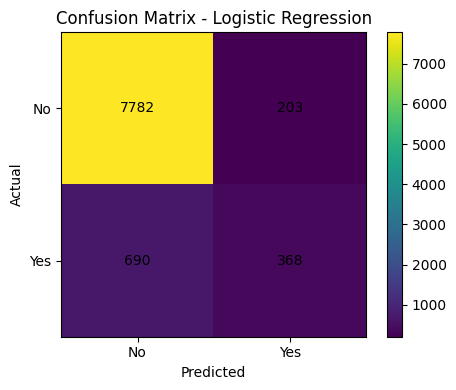

Decision Tree

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.93      0.93      7985
         Yes       0.46      0.48      0.47      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.88      0.87      0.88      9043


Confusion Matrix:
[[7406  579]
 [ 555  503]]


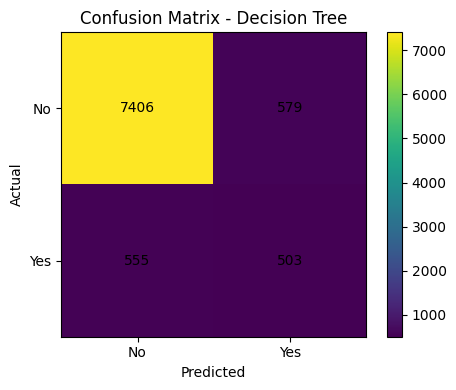

KNN

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.97      0.94      7985
         Yes       0.60      0.34      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.66      0.69      9043
weighted avg       0.88      0.90      0.88      9043


Confusion Matrix:
[[7744  241]
 [ 698  360]]


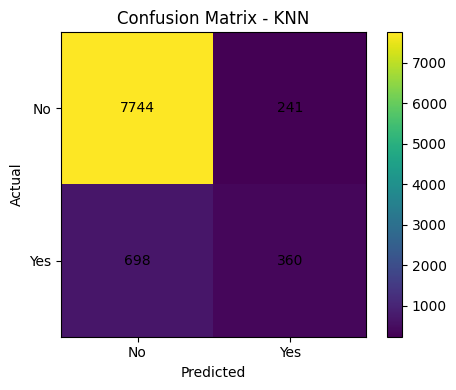

Naive Bayes

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.90      0.92      7985
         Yes       0.41      0.52      0.46      1058

    accuracy                           0.85      9043
   macro avg       0.67      0.71      0.69      9043
weighted avg       0.87      0.85      0.86      9043


Confusion Matrix:
[[7180  805]
 [ 508  550]]


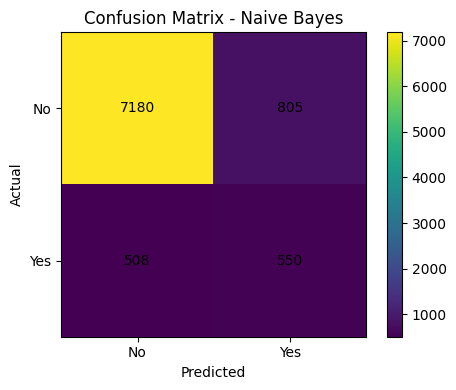

Random Forest

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.97      0.95      7985
         Yes       0.65      0.40      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043


Confusion Matrix:
[[7760  225]
 [ 639  419]]


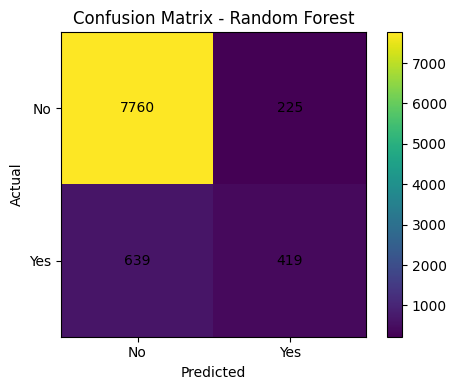

SVM

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.99      0.94      7985
         Yes       0.65      0.19      0.29      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043


Confusion Matrix:
[[7878  107]
 [ 859  199]]


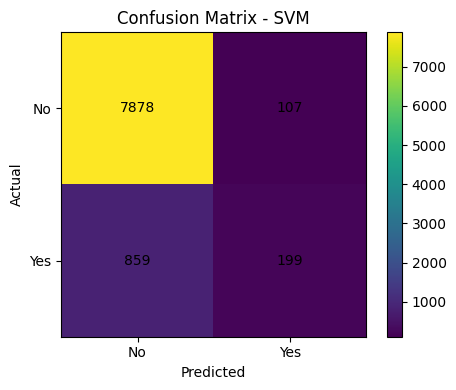

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

for name in predictions:

    y_pred = predictions[name]

    print("=" * 70)
    print(name)
    print("=" * 70)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No", "Yes"],
            zero_division=0
        )
    )

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # Plot confusion matrix using matplotlib
    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks([0, 1], ["No", "Yes"])
    plt.yticks([0, 1], ["No", "Yes"])

    # Display numbers inside cells
    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [15]:
test_data = X_test.copy()

test_data["y"] = y_test.map({
    0: "no",
    1: "yes"
})

test_data.to_csv(
    "test_data.csv",
    index=False
)

print("test_data.csv created successfully.")
print("Shape:", test_data.shape)

display(test_data.head())

test_data.csv created successfully.
Shape: (9043, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1392,40,blue-collar,married,primary,no,640,yes,yes,unknown,8,may,347,2,-1,0,unknown,no
7518,44,technician,married,secondary,no,378,yes,no,unknown,30,may,203,2,-1,0,unknown,no
12007,31,services,married,secondary,no,356,yes,no,unknown,20,jun,228,5,-1,0,unknown,no
5536,36,blue-collar,married,primary,no,655,yes,no,unknown,23,may,153,4,-1,0,unknown,no
29816,34,services,single,secondary,no,1921,yes,no,cellular,4,feb,61,1,-1,0,unknown,no


In [16]:
import os
import joblib

# Create model folder
os.makedirs("model", exist_ok=True)

# Save all trained models
for name, model in trained_models.items():
    
    # Convert model name to a safe filename
    filename = name.lower().replace(" ", "_") + ".joblib"
    
    filepath = os.path.join("model", filename)
    
    joblib.dump(model, filepath)
    
    print(f"Saved: {filepath}")

print("\nAll 6 models saved successfully.")

Saved: model/logistic_regression.joblib
Saved: model/decision_tree.joblib
Saved: model/knn.joblib
Saved: model/naive_bayes.joblib
Saved: model/random_forest.joblib
Saved: model/svm.joblib

All 6 models saved successfully.


In [17]:
import os
import joblib

# Create model folder
os.makedirs("model", exist_ok=True)

# Save all trained models
for name, model in trained_models.items():
    
    # Convert model name to a safe filename
    filename = name.lower().replace(" ", "_") + ".joblib"
    
    filepath = os.path.join("model", filename)
    
    joblib.dump(model, filepath)
    
    print(f"Saved: {filepath}")

print("\nAll 6 models saved successfully.")

Saved: model/logistic_regression.joblib
Saved: model/decision_tree.joblib
Saved: model/knn.joblib
Saved: model/naive_bayes.joblib
Saved: model/random_forest.joblib
Saved: model/svm.joblib

All 6 models saved successfully.


In [18]:
import os

print("Files inside model folder:")

for file in os.listdir("model"):
    print("-", file)

Files inside model folder:
- logistic_regression.joblib
- decision_tree.joblib
- knn.joblib
- naive_bayes.joblib
- random_forest.joblib
- svm.joblib


In [19]:
import joblib

loaded_rf = joblib.load(
    "model/random_forest.joblib"
)

rf_predictions = loaded_rf.predict(X_test)

print("Loaded Random Forest successfully.")
print("Predictions generated:", len(rf_predictions))

Loaded Random Forest successfully.
Predictions generated: 9043


In [20]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
/home/cloud/Desktop/Bank_Classification


In [21]:
import os

print("Current folder:")
print(os.getcwd())

print("\nModel files:")

for file in os.listdir("model"):
    print("-", file)

Current folder:
/home/cloud/Desktop/Bank_Classification

Model files:
- logistic_regression.joblib
- decision_tree.joblib
- knn.joblib
- naive_bayes.joblib
- random_forest.joblib
- svm.joblib


In [22]:
print(results_formatted.to_string(index=False))

           ML Model  Accuracy    AUC  Precision  Recall  F1 Score    MCC
Logistic Regression    0.9012 0.9056     0.6445  0.3478    0.4518 0.4261
      Decision Tree    0.8746 0.7015     0.4649  0.4754    0.4701 0.3990
                KNN    0.8962 0.8277     0.5990  0.3403    0.4340 0.4001
        Naive Bayes    0.8548 0.8101     0.4059  0.5198    0.4559 0.3774
      Random Forest    0.9045 0.9263     0.6506  0.3960    0.4924 0.4597
                SVM    0.8932 0.9039     0.6503  0.1881    0.2918 0.3105
